This notebook recreates Figure 7/S13 differential accessibility and human genetics plots from saved inputs.

## Setup 

In [1]:
renv::load('/oak/stanford/groups/agitler/Shared/Shared_Jupyter_Notebook_Analysis/4.1.1-OG-Multiome/')

library(ArchR)
library(future)
library(dplyr)
library(BSgenome.Mmusculus.UCSC.mm10)
library(pheatmap)
library(ggpubr)
library(ggrepel)
library(ggbreak)
library(cowplot)
library(Seurat)
library(forcats)

if(!dir.exists('/oak/stanford/groups/agitler/Shared/SOD1_Paper/Multiome')){
  dir.create('/oak/stanford/groups/agitler/Shared/SOD1_Paper/Multiome')
}
setwd('/oak/stanford/groups/agitler/Shared/SOD1_Paper/Multiome')

addArchRGenome("mm10")

plan(strategy = "multicore", workers = 16)
options(future.globals.maxSize = 41953040000)

addArchRThreads(threads = 16)


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .______      
          /   \     |   _ 

## Alpha MN differentially accessible peaks

In [2]:
#Load ArchR Project
proj_alpha <- loadArchRProject('proj_alpha')

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [3]:
# Get marker peaks
alpha_markerPeaks <- getMarkerFeatures(
    ArchRProj = proj_alpha, 
    useMatrix = "PeakMatrix",
    groupBy = "Stage",
    testMethod = "wilcoxon",
    maxCells = 1052,
    bias = c("TSSEnrichment", "log10(nFrags)"),
    useGroups = "mid-late", 
    bgdGroups = "control"
    )

ArchR logging to : ArchRLogs/ArchR-getMarkerFeatures-3e43264b01-Date-2026-06-22_Time-21-01-45.log
If there is an issue, please report to github with logFile!

MatrixClass = Sparse.Integer.Matrix

2026-06-22 21:01:46 : Matching Known Biases, 0.007 mins elapsed.

2026-06-22 21:01:47 : Computing Pairwise Tests (1 of 1), 0.038 mins elapsed.

Pairwise Test mid-late : Seqnames chr1

Pairwise Test mid-late : Seqnames chr10

Pairwise Test mid-late : Seqnames chr11

Pairwise Test mid-late : Seqnames chr12

Pairwise Test mid-late : Seqnames chr13

Pairwise Test mid-late : Seqnames chr14

Pairwise Test mid-late : Seqnames chr15

Pairwise Test mid-late : Seqnames chr16

Pairwise Test mid-late : Seqnames chr17

Pairwise Test mid-late : Seqnames chr18

Pairwise Test mid-late : Seqnames chr19

Pairwise Test mid-late : Seqnames chr2

Pairwise Test mid-late : Seqnames chr3

Pairwise Test mid-late : Seqnames chr4

Pairwise Test mid-late : Seqnames chr5

Pairwise Test mid-late : Seqnames chr6

Pairwise T

Warning message:
“'markerPlot' is deprecated.
Use 'plotMarkers' instead.
See help("Deprecated")”
Warning message:
“Removed 31 rows containing missing values (`geom_point_rast()`).”


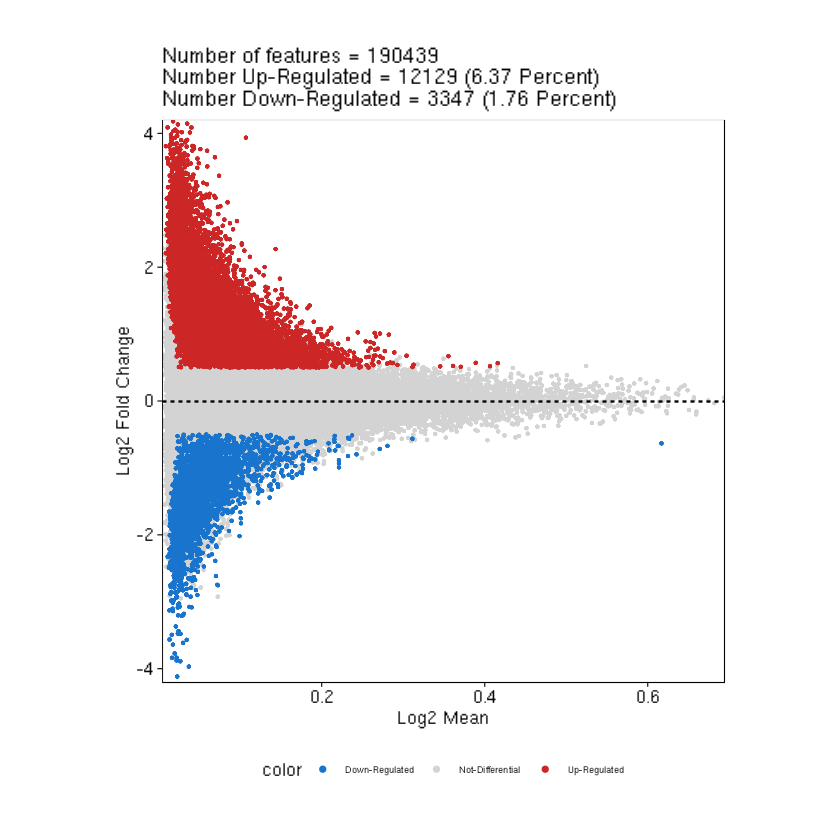

In [4]:
pma <- markerPlot(seMarker = alpha_markerPeaks, name = "mid-late", cutOff = "FDR <= 0.05 & abs(Log2FC) >= 0.5", plotAs = "MA")
pma

## LDSC disease-associated alpha MN DAR enrichment

Warning message in read.table(file = file, header = header, sep = sep, quote = quote, :
“incomplete final line found by readTableHeader on 'GWAS_LDSC_results.csv'”


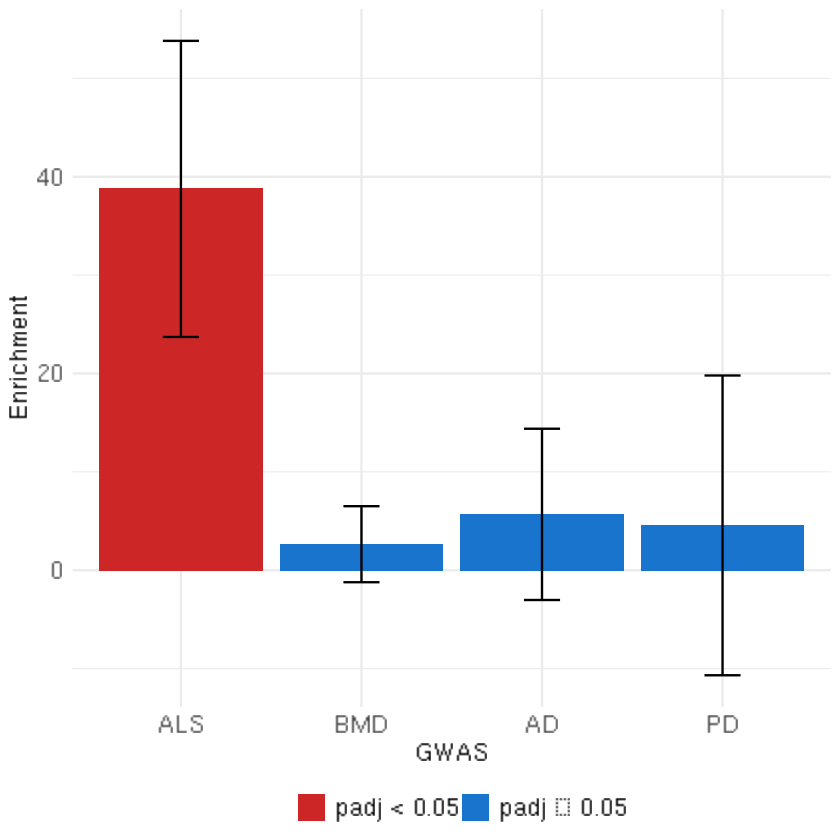

In [5]:
GWAS_LDSC_results <- read.csv(file="GWAS_LDSC_results.csv")

GWAS_LDSC_results$GWAS <- factor(GWAS_LDSC_results$GWAS, levels = c('ALS','BMD','AD','PD'))

GWAS_LDSC_barplot <- ggplot(GWAS_LDSC_results, aes(x = GWAS, y = Enrichment, fill = fct_rev(factor(Enrichment_padj < 0.05)))) +
  geom_bar(stat = "identity") +
  geom_errorbar(aes(ymin = Enrichment - Enrichment_std_error, ymax = Enrichment + Enrichment_std_error),
                width = 0.2, color = "black") +
  labs(x = "GWAS", y = "Enrichment") +
  scale_fill_manual(values = c("TRUE" = "firebrick3", "FALSE" = "dodgerblue3"),
                    name = "Significance",
                    labels = c("TRUE" = "padj < 0.05", "FALSE" = "padj \u2265 0.05")) +
  theme_minimal() +
  theme(
    axis.title = element_text(size = 14),
    axis.text = element_text(size = 14),
    legend.title = element_blank(),
    legend.text = element_text(size = 14),
    legend.position = "bottom"
  )

GWAS_LDSC_barplot

## LDSC control-DAR comparisons

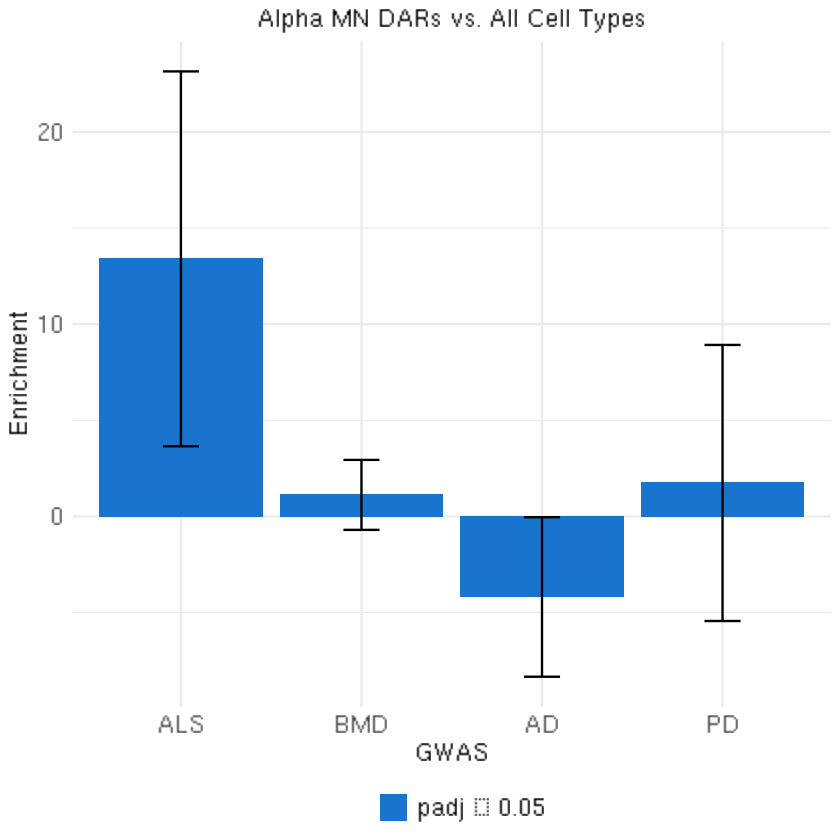

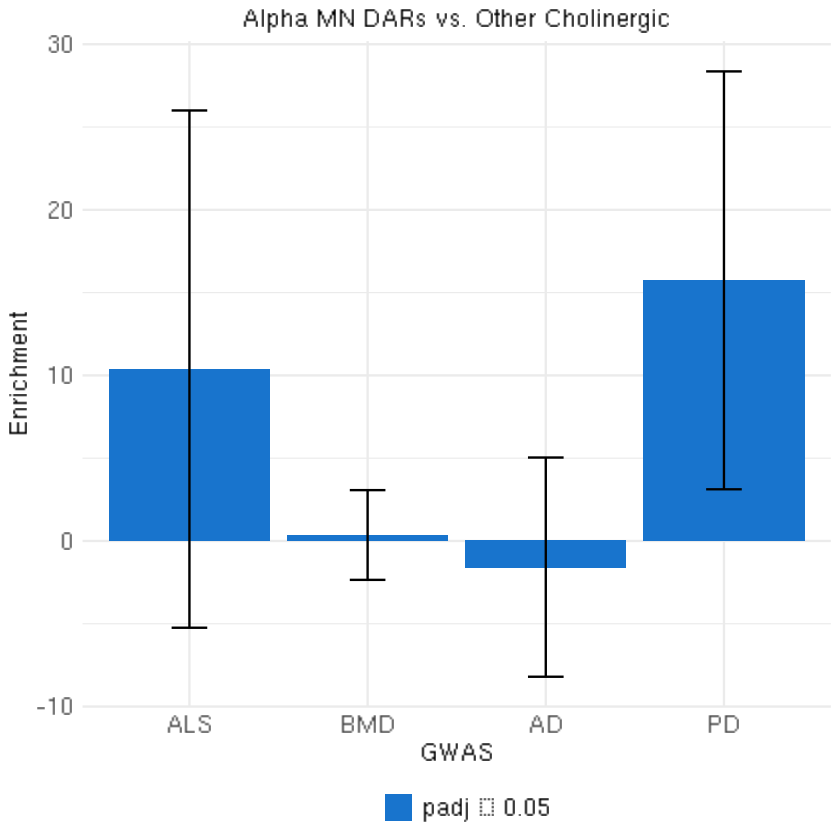

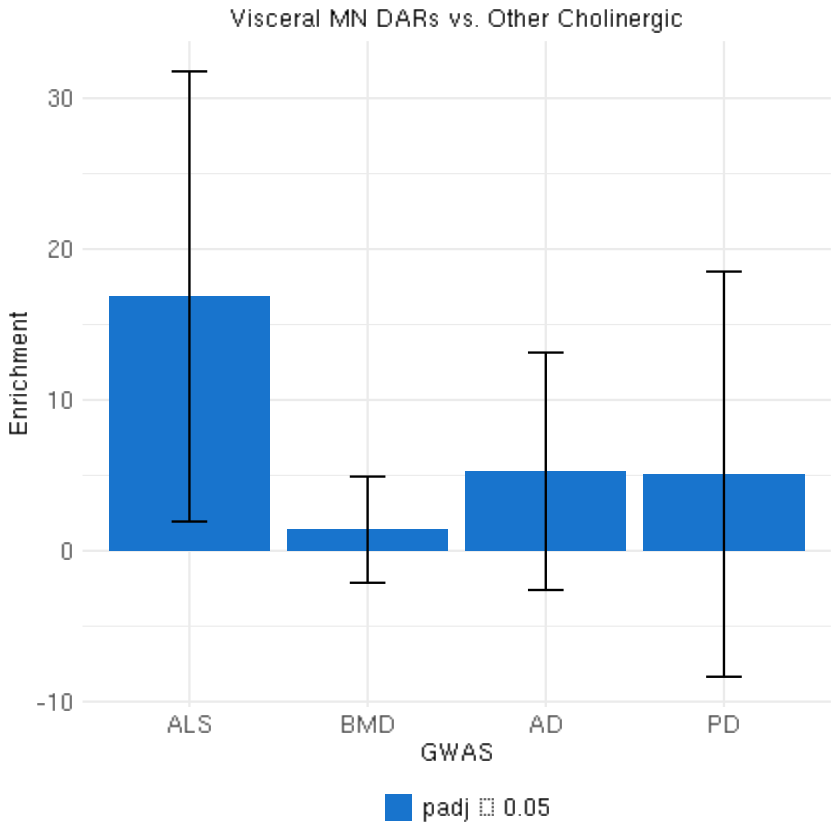

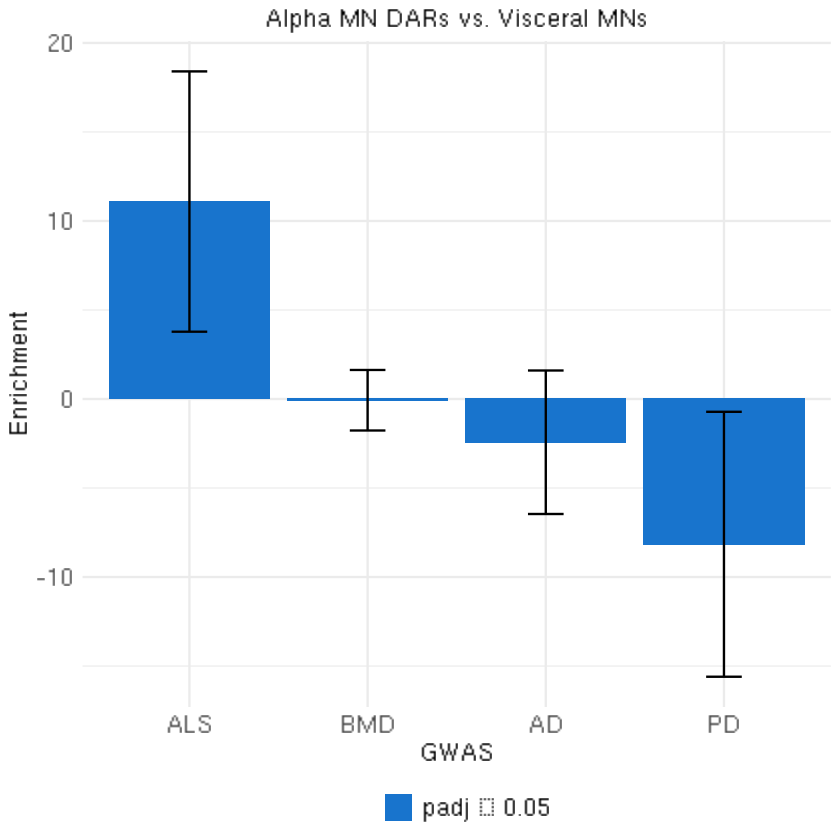

In [6]:
GWAS_LDSC_results <- read.csv(file="revisions_GWAS_LDSC_results.csv")

# --------------------------------------------------
# Prep: GWAS order and padj
# --------------------------------------------------
GWAS_LDSC_results$GWAS <- factor(
  GWAS_LDSC_results$GWAS,
  levels = c("ALS", "BMD", "AD", "PD")
)

# If Enrichment_padj doesn't exist, create it
if (!"Enrichment_padj" %in% names(GWAS_LDSC_results)) {
  GWAS_LDSC_results <- GWAS_LDSC_results %>%
    mutate(Enrichment_padj = p.adjust(Enrichment_p, method = "BH"))
}

# Helper function 
make_ldsc_plot <- function(df_sub, title_text) {
  ggplot(df_sub,
         aes(x = GWAS,
             y = Enrichment,
             fill = fct_rev(factor(Enrichment_padj < 0.05)))) +
    geom_bar(stat = "identity") +
    geom_errorbar(
      aes(ymin = Enrichment - Enrichment_std_error,
          ymax = Enrichment + Enrichment_std_error),
      width = 0.2,
      color = "black"
    ) +
    labs(x = "GWAS", y = "Enrichment", title = title_text) +
    scale_fill_manual(
      values = c("TRUE" = "firebrick3",
                 "FALSE" = "dodgerblue3"),
      name   = "Significance",
      labels = c("TRUE" = "padj < 0.05",
                 "FALSE" = "padj \u2265 0.05")
    ) +
    theme_minimal() +
    theme(
      axis.title  = element_text(size = 14),
      axis.text   = element_text(size = 14),
      legend.title = element_blank(),
      legend.text  = element_text(size = 14),
      legend.position = "bottom",
      plot.title = element_text(size = 14, hjust = 0.5)
    )
}

# --------------------------------------------------
# Alpha MN DARs vs. All Cell Types
# --------------------------------------------------
df_alpha_all <- GWAS_LDSC_results %>%
  filter(module == "alpha MN",
         Comparison == "Cell type specific DARs among all cell types")

p_alpha_all <- make_ldsc_plot(
  df_alpha_all,
  "Alpha MN DARs vs. All Cell Types"
)

# --------------------------------------------------
# Alpha MN DARs vs. Other Cholinergic
# --------------------------------------------------
df_alpha_chol <- GWAS_LDSC_results %>%
  filter(module == "alpha MN",
         Comparison == "Cell type specific DARs in cholinergic neurons")

p_alpha_chol <- make_ldsc_plot(
  df_alpha_chol,
  "Alpha MN DARs vs. Other Cholinergic"
)

# --------------------------------------------------
# Visceral MN DARs vs. Other Cholinergic
# --------------------------------------------------
df_visceral_chol <- GWAS_LDSC_results %>%
  filter(module == "visceral MN",
         Comparison == "Cell type specific DARs in cholinergic neurons")

p_visceral_chol <- make_ldsc_plot(
  df_visceral_chol,
  "Visceral MN DARs vs. Other Cholinergic"
)

# --------------------------------------------------
# Alpha vs. Visceral MN DARs
# --------------------------------------------------
df_alpha_vs_visceral <- GWAS_LDSC_results %>%
  filter(module == "alpha_vs_visceral MN",
         Comparison == "AlphaMN_vs_visceralMN_DARs")

p_alpha_vs_visceral <- make_ldsc_plot(
  df_alpha_vs_visceral,
  "Alpha MN DARs vs. Visceral MNs"
)

# Display plots
p_alpha_all
p_alpha_chol
p_visceral_chol
p_alpha_vs_visceral

## H-MAGMA candidate ALS gene plot

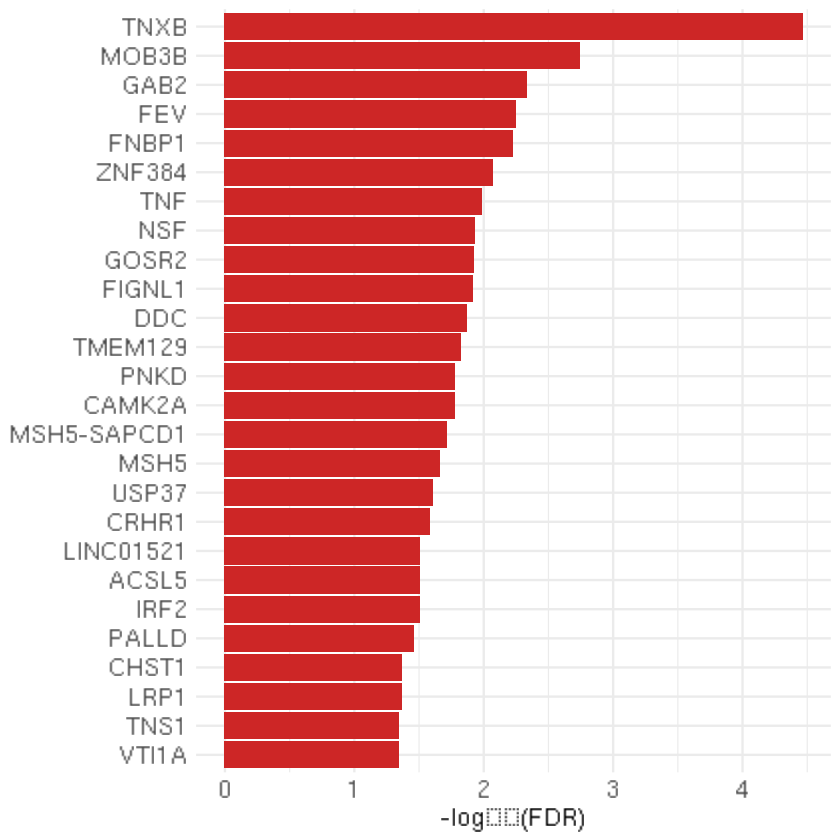

In [7]:
HMAGMA_results <- read.csv(file="HMAGMA_ALS2021Euro_vs_hg19_control_late_peaks_overlap.csv")

HMAGMA_results_sorted <- HMAGMA_results %>% arrange(FDR)

HMAGMA_results_sig <- HMAGMA_results_sorted %>% filter(FDR < 0.05)
HMAGMA_results_sig <- HMAGMA_results_sig %>% mutate(neg_log10FDR = -log10(FDR))
HMAGMA_results_sig <- HMAGMA_results_sig %>% mutate(SYMBOL = if_else(GENE == "ENSG00000213888", "LINC01521", SYMBOL))

hmagma_barplot <- ggplot(HMAGMA_results_sig,
       aes(x = neg_log10FDR,
           y = reorder(SYMBOL, neg_log10FDR))) +
  geom_col(fill = "firebrick3") +
  labs(x = "-log\u2081\u2080(FDR)",
       y = NULL,
       title = NULL) +
  theme_minimal() +
  theme(
    axis.title.x = element_text(size = 14),
    axis.text.y  = element_text(size = 14),
    axis.text.x  = element_text(size = 14)
  )

hmagma_barplot

## Candidate-gene expression heatmap

Warning message:
“The following 2 features were not found in the integrated assay: Crhr1, Gosr2”


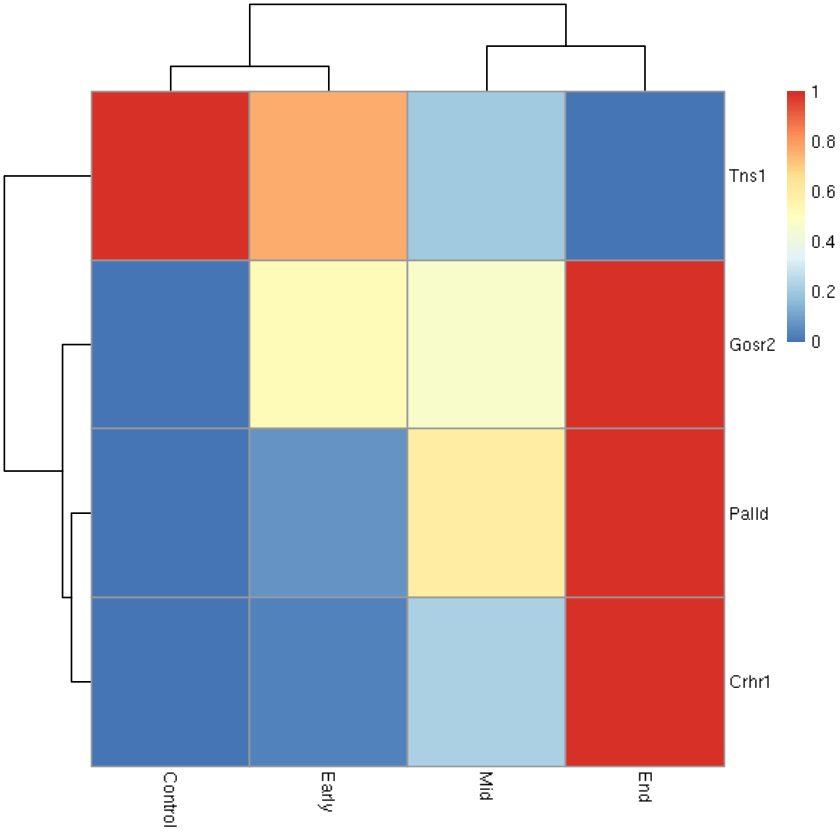

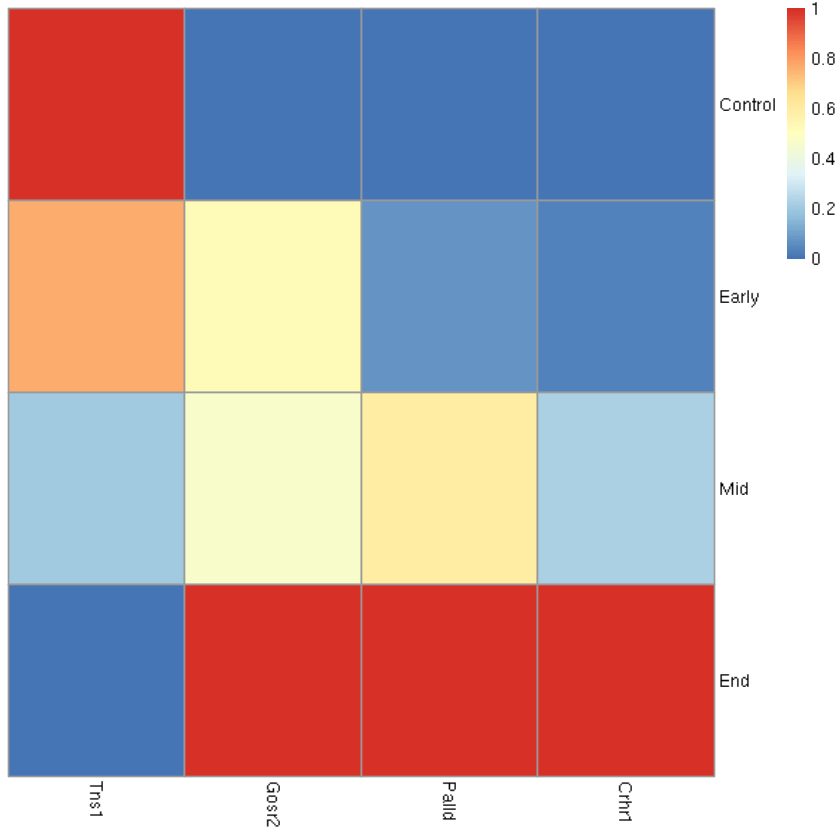

In [8]:
alpha_disease_diffexp_rnaOnly <- read.csv("/oak/stanford/groups/agitler/Shared/SOD1_Paper/RNA/DESeq2/Cholinergic_Type/Alpha MNs_sod.end_vs_ctl.csv")

HMAGMA_results_sig_mod <- HMAGMA_results_sig %>%
  mutate(SYMBOL = str_replace(SYMBOL, "^(\\w)(.*)", function(x) {
    paste0(str_to_upper(str_sub(x, 1, 1)), str_to_lower(str_sub(x, 2)))
  }))

all.markers <- dplyr::filter(alpha_disease_diffexp_rnaOnly, X %in% HMAGMA_results_sig_mod$SYMBOL & padj < 0.01)

alpha_label_transfer_50 <- readRDS(file = '/oak/stanford/groups/agitler/Shared/SOD1_Paper/RNA/rds_files/alpha_label_transfer_50.rds')

Idents(alpha_label_transfer_50) <- alpha_label_transfer_50$stage
heatmap.avgexp <- AverageExpression(alpha_label_transfer_50, features=all.markers$X)$RNA
heatmap.avgexp <- (heatmap.avgexp - rowMins(heatmap.avgexp))/(rowMaxs(heatmap.avgexp) - rowMins(heatmap.avgexp))

# define the mapping
new_names <- c(
  ctl        = "Control",
  sod.early  = "Early",
  sod.mid    = "Mid",
  sod.end    = "End"
)

# apply it to the matrix
colnames(heatmap.avgexp) <- new_names[colnames(heatmap.avgexp)]

pheatmap(heatmap.avgexp)

col_order <- c('Control','Early','Mid','End')
heatmap.avgexp <- heatmap.avgexp[,col_order]

row_order <- c('Tns1','Gosr2','Palld','Crhr1')
heatmap.avgexp <- heatmap.avgexp[row_order,]

pheatmap(t(heatmap.avgexp), cluster_rows = FALSE, cluster_cols = FALSE)